In [1]:
import torch
from src.evaluator import ShadeEvaluator
from datetime import datetime
import pandas as pd

from src.visualization import plot_losses, display_res

In [2]:
# Instantiate Evaluator
RESULTS_DIR = "/Users/luc/Geomatics/model_data_case_study/324269/output"
CHECKPOINT_PATH = "../results/ams_masked/results/checkpoint_69.ckpt"
device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
else "cpu")
print(device)

evaluator = ShadeEvaluator(device, CHECKPOINT_PATH, RESULTS_DIR)

Seed set to 42


mps
Model initialized...


In [11]:
# Test evaluation
# test_tile = "/Users/luc/Geomatics/Thesis/training_data/271110/input/271110_p_189_2022_06_02_dsm.tif"
# test_tile_mask = "/Users/luc/Geomatics/Thesis/misc_data/input/271110_Ams/test_tiles/canopy_mask/271110_p_189_2022_06_02_rgb_segmented.tif"

test_tile = "/Users/luc/Geomatics/Thesis/testing_data/271110/input/271110_p_403_2022_06_02_dsm.tif"
test_tile_mask = "/Users/luc/Geomatics/Thesis/testing_data/271110/masks/271110_p_403_2022_06_02_rgb_segmented.tif"

date_time = datetime(2024, 5, 15, 17, 30, 0, 0)
evaluator.generate_and_write_output(test_tile, test_tile_mask, date_time, overlap=64, crop=True,
                                    filename="c99_403_o64_49")

# METRICS

In [ ]:
TEST_DATA_PATH = "/Users/luc/Geomatics/Thesis/testing_data/"
CSV_PATH = "/Users/luc/Geomatics/Thesis/ShadyShenanigans/results/ams_masked/results/evaluation"

strategies = ["stitch"]
overlaps = [0, 32, 64, 96, 128]

# Generate metrics for all combinations of strategies, and overlaps (10 total)
for strategy in strategies:
    for overlap in overlaps:
        print(f"--- PROCESSING {strategy} and {overlap} ---")
        evaluator.write_metrics_csv(TEST_DATA_PATH, CSV_PATH, filename=f"metrics_{strategy}_{overlap}",
                                    strategy=strategy, overlap=overlap)

# CASE STUDY

In [3]:
import time

TEST_DATA_PATH = "/Users/luc/Geomatics/model_data_case_study/"
CSV_PATH = "/Users/luc/Geomatics/model_data_case_study/324269/metrics"

# Separate timing for just generation and writing of outputs (comparable to slim shady)
start_time = time.time()
evaluator.generate_outputs(TEST_DATA_PATH, overlap=64, building_only=False)
end_time = time.time() - start_time
print(end_time)

# Write metrics about case study 1394.6528961658478 (building) 2248.391663789749 (full)
evaluator.write_metrics_csv(TEST_DATA_PATH, CSV_PATH, filename=f"metrics_case_study", overlap=64, building_only=False)

Processing city with osmid: 324269
Writing for tile: 18...


/opt/miniconda3/envs/ShadyEnv/lib/python3.13/site-packages/pysolar/solartime.py:115: UserWarning: Leap seconds for year 2025 are not available for the installed version of pysolar
  warnings.warn \


Skipped 0 due to zenith < 15 degrees
Writing for tile: 7...
Skipped 0 due to zenith < 15 degrees
Writing for tile: 20...
Skipped 0 due to zenith < 15 degrees
Writing for tile: 13...
Skipped 0 due to zenith < 15 degrees
Writing for tile: 12...
Skipped 0 due to zenith < 15 degrees
Writing for tile: 11...
Skipped 0 due to zenith < 15 degrees
Writing for tile: 6...
Skipped 0 due to zenith < 15 degrees
Writing for tile: 19...
Skipped 0 due to zenith < 15 degrees
Writing for tile: 5...
Skipped 0 due to zenith < 15 degrees
2248.391663789749
Processing city with osmid: 324269
Writing for tile: 18...


100%|██████████| 76/76 [04:49<00:00,  3.81s/it]


Skipped 0 due to zenith < 15 degrees
Writing for tile: 7...


...

Skipped 0 due to zenith < 15 degrees
Writing for tile: 19...


100%|██████████| 76/76 [04:48<00:00,  3.79s/it]


Skipped 0 due to zenith < 15 degrees
Writing for tile: 5...


100%|██████████| 76/76 [04:53<00:00,  3.86s/it]

Skipped 0 due to zenith < 15 degrees


# VISUALIZATION

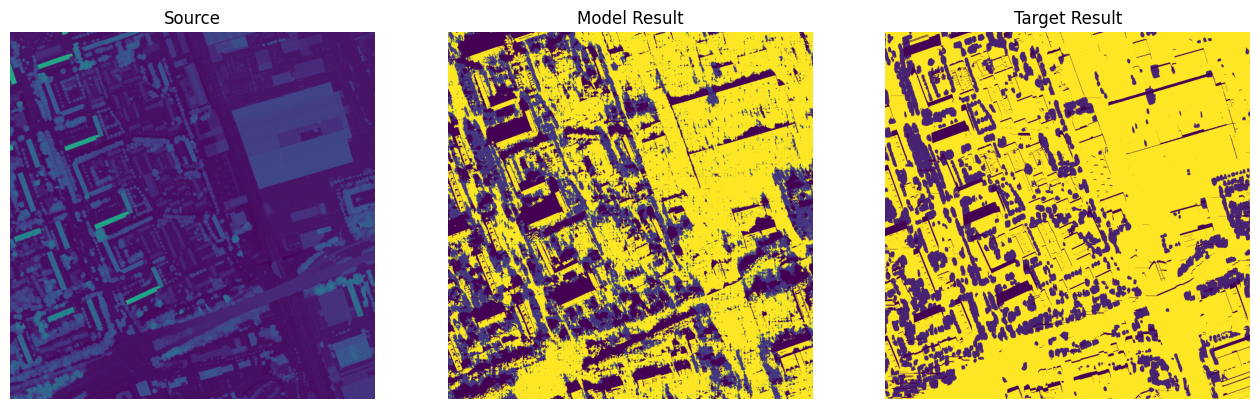

In [6]:
# test_tile = "/Users/luc/Geomatics/Thesis/testing_data/271110/input/271110_p_403_2022_06_02_dsm.tif"
# result_tile = "/Users/luc/Geomatics/Thesis/ShadyShenanigans/results/ams_masked/c99_403_o64.tif"
# target_tile = "/Users/luc/Geomatics/Thesis/testing_data/271110/targets/403/271110_p_403_Shadow_20240515_1730_LST.tif"

# test_tile = "/Users/luc/Geomatics/Thesis/misc_data/input/271110_Ams/test_tiles/dsms/combined/271110_p_189_2022_06_02_dsm.tif"
# result_tile = "/Users/luc/Geomatics/Thesis/ShadyShenanigans/results/ams_masked/c99_189_o64.tif"
# target_tile = "/Users/luc/Geomatics/Thesis/training_data/271110/targets/189/271110_p_189_Shadow_20240515_1730_LST.tif"

test_tile = "/Users/luc/Geomatics/model_data_case_study/324269/input/324269_p_11_2021_05_29_dsm.tif"
result_tile = "/Users/luc/Geomatics/model_data_case_study/324269/output/11/324269_p_11_20260620_1330_model.tif"
target_tile = "/Users/luc/Geomatics/model_data_case_study/324269/targets/11/324269_p_11_Shadow_20260620_1330_LST.tif"

display_res(test_tile, result_tile, target_tile)

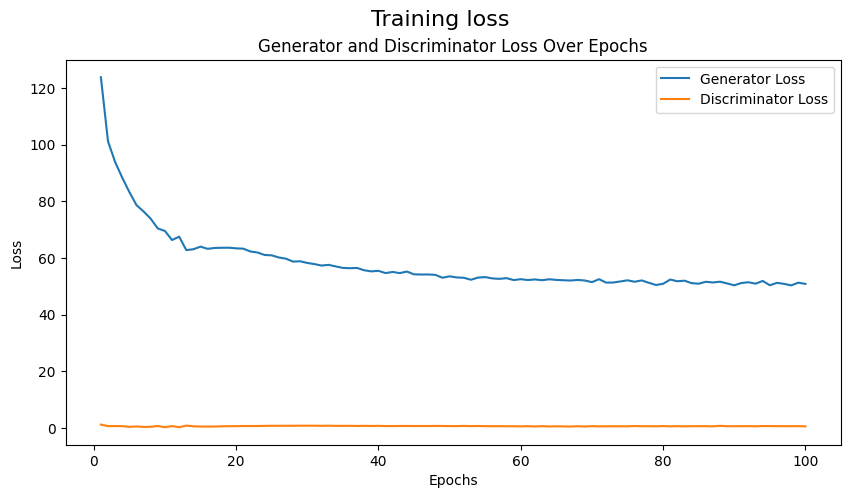

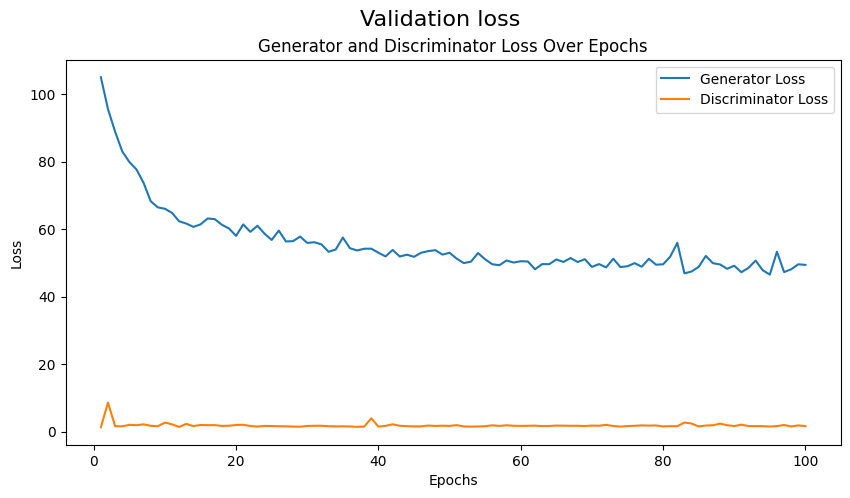

In [5]:
df = pd.read_csv(
    "/Users/luc/Geomatics/Thesis/ShadyShenanigans/results/ams_masked/results/loss_logs/version_0/metrics.csv")

g_train = df["train_g_losses"]
d_train = df["train_d_losses"]
g_val = df["val_g_losses"]
d_val = df["val_d_losses"]

plot_losses(g_train, d_train, title="Training loss")
plot_losses(g_val, d_val, title="Validation loss")